Customer Booking Prediction Model
British Airways - Data Science Task
======================================
Predicts whether a customer will complete a holiday booking
using a Random Forest classifier.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score , StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        roc_auc_score,
        ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

### Load Data

In [3]:
df = pd.read_csv('F:/Downloads/customer_booking.csv', encoding = 'latin1')

In [5]:
print(f'Dataset Shape : {df.shape}')

Dataset Shape : (50000, 14)


In [6]:
print(f'\n target Distribution : \n{df['booking_complete'].value_counts()}')


 target Distribution : 
booking_complete
0    42522
1     7478
Name: count, dtype: int64


### Feature Engineering

In [7]:
df['total_extras'] = (
    df['wants_extra_baggage']
    + df['wants_preferred_seat']
    + df['wants_in_flight_meals']
)

df['wants_any_extra'] = (df['total_extras'] > 0).astype(int)

Boolean Convenience Flags

In [8]:
df['is_weekend_flight'] = df['flight_day'].isin(['Sat','Sun']).astype(int)
df["is_roundtrip"] = (df["trip_type"] == "RoundTrip").astype(int)
df["is_internet"] = (df["sales_channel"] == "Internet").astype(int)

In [12]:
# Booking urgency bucket (0 = very far in advance, 4 = last-minute)
df['booking_urgency'] = pd.cut(
    df['purchase_lead'],
    bins = [0, 7, 30, 90, 300, 870],
    labels = [4 , 3, 2, 1, 0]
).astype(float)

In [13]:
# Encode high-cardinality categoricals
le = LabelEncoder()
df["route_enc"] = le.fit_transform(df["route"])
df["booking_origin_enc"] = le.fit_transform(df["booking_origin"])

### Define Feature and Target

In [14]:
FEATURES = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "total_extras",
    "wants_any_extra",
    "is_weekend_flight",
    "is_roundtrip",
    "is_internet",
    "booking_urgency",
    "route_enc",
    "booking_origin_enc",
]

In [16]:
X = df[FEATURES]
y = df['booking_complete']

### Train Random Forest With Cross Valiadation

In [17]:
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1,
    class_weight = 'balanced' # handles class imbalance (85/15 split)
)

In [18]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [19]:
cv_auc = cross_val_score(rf, X, y, cv = cv, scoring = 'roc_auc', n_jobs = -1)
cv_acc = cross_val_score(rf, X, y, cv = cv, scoring = 'accuracy', n_jobs = -1)
cv_f1 = cross_val_score(rf, X, y, cv = cv, scoring = 'f1', n_jobs = -1)
cv_pre = cross_val_score(rf, X, y, cv = cv, scoring = 'precision', n_jobs = -1)
cv_rec = cross_val_score(rf, X, y, cv = cv, scoring = 'recall', n_jobs = -1)

In [21]:
print("\n=== 5-Fold Cross-Validation Results ===")
print(f'ROC-AUC : {cv_auc.mean():.2f} +- {cv_auc.std():.2f}')
print(f'Accuracy : {cv_acc.mean():.2f} +- {cv_acc.std():.2f}')
print(f'F1 Score : {cv_f1.mean():.2f} +- {cv_f1.std():.2f}')
print(f'Precision : {cv_pre.mean():.2f} +- {cv_pre.std():.2f}')
print(f'Recall : {cv_rec.mean():.2f} +- {cv_rec.std():.2f}')


=== 5-Fold Cross-Validation Results ===
ROC-AUC : 0.77 +- 0.00
Accuracy : 0.71 +- 0.00
F1 Score : 0.42 +- 0.00
Precision : 0.30 +- 0.00
Recall : 0.69 +- 0.01


### Fit on Full Dataset

In [22]:
rf.fit(X, y)
y_pred = rf.predict(X)
y_pred_prob = rf.predict_proba(X)[:, 1]

In [23]:
print("\n=== Full-Dataset Classification Report ===")
print(classification_report(y, y_pred, target_names = ['Not booked','Booked']))
print(f'Full-dataset ROC-AUC : {roc_auc_score(y, y_pred_prob):.2f}')


=== Full-Dataset Classification Report ===
              precision    recall  f1-score   support

  Not booked       0.95      0.72      0.82     42522
      Booked       0.34      0.80      0.47      7478

    accuracy                           0.73     50000
   macro avg       0.65      0.76      0.65     50000
weighted avg       0.86      0.73      0.77     50000

Full-dataset ROC-AUC : 0.83


### Feature Importance Plot

In [24]:
importances = (
    pd.Series(rf.feature_importances_, index = FEATURES).sort_values(ascending = True)
)

In [25]:
palette = [
    '#A8D8EA' if v < 0.05
    else '#1C7293' if v < 0.12
    else '#065A82'
    for v in importances.values
]

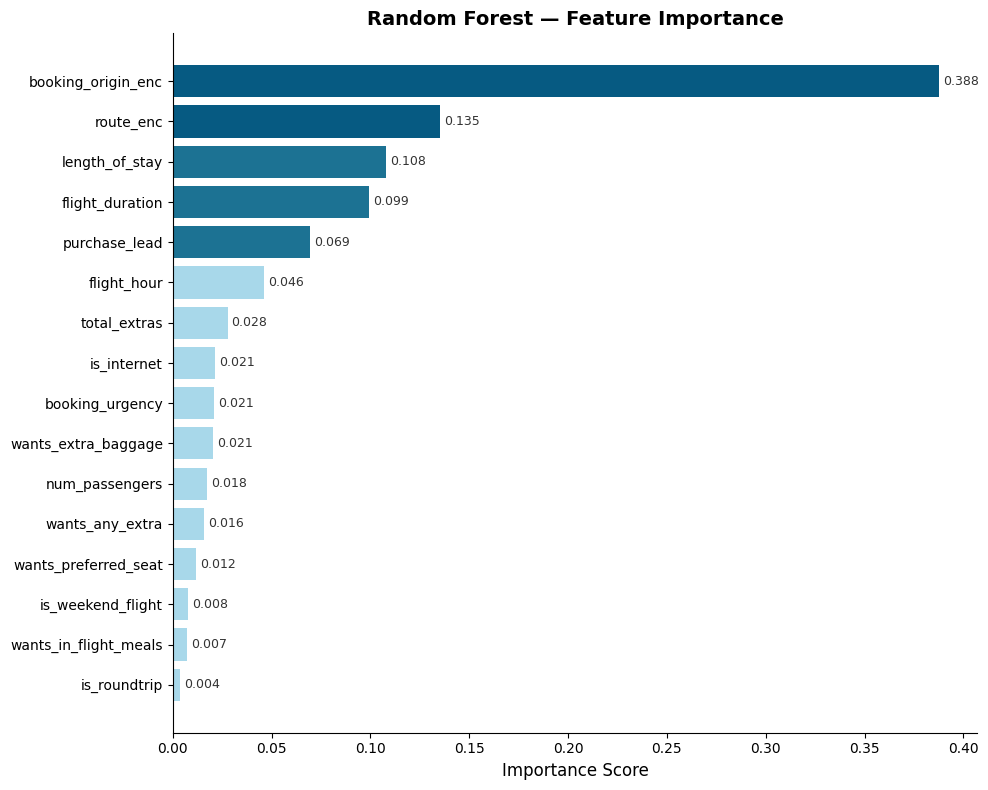


Saved: feature_importance.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color=palette)
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Random Forest — Feature Importance", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9, color="#333333")
plt.tight_layout()
plt.show()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("\nSaved: feature_importance.png")


### Confusion Matrix Plot

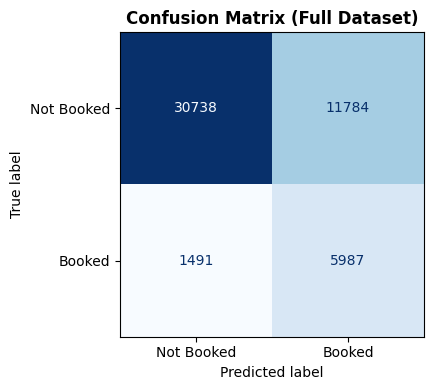

Saved: confusion_matrix.png

Done! ✓


In [29]:
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Booked", "Booked"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix (Full Dataset)", fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved: confusion_matrix.png")
 
print("\nDone! ✓")